In [1]:
!pip install -U transformers accelerate bitsandbytes sentencepiece huggingface_hub safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 83.5 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: transformers
    Found existing installat

In [2]:
from huggingface_hub import snapshot_download

MODEL_ID = "deepseek-ai/DeepSeek-Prover-V1.5-SFT"

model_dir = snapshot_download(
    repo_id=MODEL_ID,
    local_dir="/kaggle/working/DeepSeek-Prover-V1.5-SFT",
    local_dir_use_symlinks=False
)

print(model_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

/kaggle/working/DeepSeek-Prover-V1.5-SFT


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_PATH = "/kaggle/working/DeepSeek-Prover-V1.5-SFT"

compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=compute_dtype,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(102400, 4096)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
      )
    )
    (norm): LlamaRM

In [4]:
def make_prompt(code_prefix: str) -> str:
    return "Complete the following Lean 4 code:\n\n```lean4\n\n" + code_prefix

In [5]:
code_prefix = """import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by
"""
prompt = make_prompt(code_prefix)
print(prompt)

Complete the following Lean 4 code:

```lean4

import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by



In [8]:
def generate_proof(code_prefix, max_new_tokens=256, temperature=0.7, top_p=0.95, do_sample=True):
    prompt = make_prompt(code_prefix)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(out[0], skip_special_tokens=True)
    completion = full_text[len(prompt):]

    if "```" in completion:
        completion = completion.split("```")[0]

    return completion.strip(), code_prefix + completion.strip()

In [13]:
code_prefix = """import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by
"""

completion, full_code = generate_proof(code_prefix, max_new_tokens=128, do_sample=False)

print("=== COMPLETION ===")
print(completion)
print("\n=== FULL CODE ===")
print(full_code)

=== COMPLETION ===
  simpa using Nat.add_zero n

=== FULL CODE ===
import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by
  simpa using Nat.add_zero n


In [14]:
tests = [
"""import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by
""",

"""import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_eq_symm {α : Type} (x y : α) (h : x = y) : y = x := by
""",

"""import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_and_intro (A B : Prop) (hA : A) (hB : B) : A ∧ B := by
""",

"""import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_exists (P : Nat → Prop) (h : P 0) : ∃ n, P n := by
"""
]

for i, code_prefix in enumerate(tests):
    completion, full_code = generate_proof(code_prefix, max_new_tokens=128, do_sample=False)
    print(f"\n\n===== TEST {i} =====")
    print("COMPLETION:")
    print(completion)
    print("\nFULL CODE:")
    print(full_code)


===== TEST 0 =====
COMPLETION:
simpa using Nat.add_zero n

FULL CODE:
import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_add_zero (n : Nat) : n + 0 = n := by
simpa using Nat.add_zero n


===== TEST 1 =====
COMPLETION:
exact h.symm

FULL CODE:
import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_eq_symm {α : Type} (x y : α) (h : x = y) : y = x := by
exact h.symm


===== TEST 2 =====
COMPLETION:
exact ⟨hA, hB⟩

FULL CODE:
import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_and_intro (A B : Prop) (hA : A) (hB : B) : A ∧ B := by
exact ⟨hA, hB⟩


===== TEST 3 =====
COMPLETION:
exact ⟨0, h⟩

FULL CODE:
import Mathlib
import Aesop

set_option maxHeartbeats 0

theorem test_exists (P : Nat → Prop) (h : P 0) : ∃ n, P n := by
exact ⟨0, h⟩



In [16]:
!pip install -q datasets pyarrow tqdm

In [17]:
import re, json, random, os, math
import pandas as pd
import torch
from tqdm.auto import tqdm
from datasets import load_dataset, get_dataset_split_names, Dataset, concatenate_datasets

In [18]:
SEED = 42
random.seed(SEED)

def load_all_splits(repo):
    splits = get_dataset_split_names(repo)
    print(repo, "splits:", splits)
    out = {}
    for sp in splits:
        try:
            out[sp] = load_dataset(repo, split=sp)
            print("loaded", sp, len(out[sp]), out[sp].column_names)
        except Exception as e:
            print("failed", sp, e)
    return out

lw = load_all_splits("internlm/Lean-Workbook")

README.md: 0.00B [00:00, ?B/s]

internlm/Lean-Workbook splits: ['train']


wkbk_1009.parquet:   0%|          | 0.00/4.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25214 [00:00<?, ? examples/s]

loaded train 25214 ['id', 'status', 'tactic', 'state_before', 'state_after', 'natural_language_statement', 'answer', 'formal_statement']


In [21]:
ID_COLS = ["id", "problem_id", "name", "theorem_name", "uid"]
STATEMENT_COLS = ["formal_statement", "statement", "lean_statement", "formal_stmt", "theorem", "lean"]
PROOF_COLS = ["formal_proof", "proof", "full_proof", "lean_proof"]

def pick_col(row, cols):
    for c in cols:
        if c in row and row[c] is not None and str(row[c]).strip():
            return c, str(row[c])
    return None, ""

def extract_theorem_name(code):
    m = re.search(r"\btheorem\s+([A-Za-z0-9_'.]+)", code)
    return m.group(1) if m else None

def clean_code_fences(x):
    x = re.sub(r"```(?:lean4|lean)?", "", x)
    x = x.replace("```", "")
    return x.strip()

def to_code_prefix(formal_statement):
    s = clean_code_fences(formal_statement)
    if not re.search(r"^\s*import\s+", s, re.M):
        header = "import Mathlib\nimport Aesop\n\nset_option maxHeartbeats 0\n\n"
    else:
        header = ""
    m = re.search(r":=\s*by\b", s)
    if m:
        prefix = s[:m.end()].rstrip() + "\n"
    else:
        prefix = s.rstrip()
        if not prefix.endswith(":= by"):
            prefix += " := by"
        prefix += "\n"
    return header + prefix

def estimate_proof_steps(proof):
    if not proof:
        return None
    proof = clean_code_fences(proof)
    if ":= by" in proof:
        proof = proof.split(":= by", 1)[1]
    lines = []
    for ln in proof.splitlines():
        ln = ln.strip()
        if not ln or ln.startswith("--") or ln.startswith("/-"):
            continue
        lines.append(ln)
    return len(lines)

def row_to_task(row, source):
    id_col, rid = pick_col(row, ID_COLS)
    stmt_col, stmt = pick_col(row, STATEMENT_COLS)
    proof_col, proof = pick_col(row, PROOF_COLS)
    if not stmt:
        return None
    code_prefix = to_code_prefix(stmt)
    name = extract_theorem_name(code_prefix) or rid or f"unknown_{random.randint(0,10**9)}"
    return {
        "task_id": rid or name,
        "source": source,
        "theorem_name": name,
        "formal_statement_raw": stmt,
        "code_prefix": code_prefix,
        "has_reference_proof": bool(proof),
        "reference_proof_steps": estimate_proof_steps(proof),
        "reference_proof_raw": proof
    }

def dataset_to_tasks(ds, source, max_scan=None):
    tasks = []
    n = len(ds) if max_scan is None else min(max_scan, len(ds))
    for i in tqdm(range(n), desc=f"to tasks: {source}"):
        t = row_to_task(ds[i], source)
        if t and "theorem " in t["code_prefix"]:
            tasks.append(t)
    return tasks

In [23]:
def sample_list(xs, n):
    if n <= 0 or not xs:
        return []
    return random.sample(xs, min(n, len(xs)))

all_task_groups = {}

for split_name, ds in lw.items():
    src = f"Lean-Workbook::{split_name}"
    all_task_groups[src] = dataset_to_tasks(ds, src, max_scan=20000)

for k, v in all_task_groups.items():
    print(k, len(v))

to tasks: Lean-Workbook::train:   0%|          | 0/20000 [00:00<?, ?it/s]

Lean-Workbook::train 20000


In [24]:
MIX_CONFIG = {
    "workbook": 100,
    "workbook_plus": 100,
    "with_reference_proof": 100,
}

workbook_tasks, workbook_plus_tasks, proof_tasks = [], [], []

for src, tasks in all_task_groups.items():
    src_low = src.lower()
    if "plus" in src_low:
        workbook_plus_tasks.extend(tasks)
    else:
        workbook_tasks.extend(tasks)
    proof_tasks.extend([t for t in tasks if t["has_reference_proof"]])

selected_tasks = []
selected_tasks += sample_list(workbook_tasks, MIX_CONFIG["workbook"])
selected_tasks += sample_list(workbook_plus_tasks, MIX_CONFIG["workbook_plus"])
selected_tasks += sample_list(proof_tasks, MIX_CONFIG["with_reference_proof"])

seen = set()
dedup = []
for t in selected_tasks:
    key = (t["theorem_name"], t["code_prefix"])
    if key not in seen:
        seen.add(key)
        dedup.append(t)

selected_tasks = dedup
print("selected tasks:", len(selected_tasks))

tasks_df = pd.DataFrame(selected_tasks)
tasks_df[["task_id", "source", "theorem_name", "has_reference_proof", "reference_proof_steps"]].head(20)

selected tasks: 97


,task_id,source,theorem_name,has_reference_proof,reference_proof_steps
0,lean_workbook_plus_11559,Lean-Workbook::train,lean_workbook_plus_11559,False,None
1,lean_workbook_plus_2319,Lean-Workbook::train,lean_workbook_plus_2319,False,None
2,lean_workbook_plus_28082,Lean-Workbook::train,lean_workbook_plus_28082,False,None
3,lean_workbook_plus_24740,Lean-Workbook::train,lean_workbook_plus_24740,False,None
4,lean_workbook_plus_22462,Lean-Workbook::train,lean_workbook_plus_22462,False,None
5,lean_workbook_plus_14673,Lean-Workbook::train,lean_workbook_plus_14673,False,None
6,lean_workbook_plus_10318,Lean-Workbook::train,lean_workbook_plus_10318,False,None
7,lean_workbook_plus_57779,Lean-Workbook::train,lean_workbook_plus_57779,False,None
8,lean_workbook_plus_8594,Lean-Workbook::train,lean_workbook_plus_8594,False,None
9,lean_workbook_plus_62716,Lean-Workbook::train,lean_workbook_plus_62716,False,None


In [25]:
os.makedirs("/kaggle/working/lean_pipeline", exist_ok=True)
tasks_df.to_parquet("/kaggle/working/lean_pipeline/selected_tasks.parquet", index=False)
tasks_df.to_csv("/kaggle/working/lean_pipeline/selected_tasks.csv", index=False)

In [26]:
def make_prompt(code_prefix):
    return "Complete the following Lean 4 code:\n\n```lean4\n\n" + code_prefix

def clean_completion(completion):
    completion = completion.replace("\r\n", "\n")
    if "```" in completion:
        completion = completion.split("```")[0]
    return completion.strip()

@torch.no_grad()
def generate_candidates_for_task(code_prefix, n=4, max_new_tokens=256, temperature=0.9, top_p=0.95):
    prompt = make_prompt(code_prefix)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        num_return_sequences=n,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )
    candidates = []
    for j, seq in enumerate(out):
        text = tokenizer.decode(seq, skip_special_tokens=True)
        completion = text[len(prompt):] if text.startswith(prompt) else text
        completion = clean_completion(completion)
        candidates.append({
            "sample_id": j,
            "completion": completion,
            "full_code": code_prefix + completion
        })
    return candidates

In [28]:
N_CANDIDATES = 4
MAX_NEW_TOKENS = 256
OUT_JSONL = "/kaggle/working/lean_pipeline/generated_trajectories.jsonl"

with open(OUT_JSONL, "w", encoding="utf-8") as f:
    for task_idx, task in tqdm(list(enumerate(selected_tasks)), desc="generating"):
        try:
            cands = generate_candidates_for_task(
                task["code_prefix"],
                n=N_CANDIDATES,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=0.9,
                top_p=0.95
            )
            for c in cands:
                rec = {
                    "task_idx": task_idx,
                    "task_id": task["task_id"],
                    "source": task["source"],
                    "theorem_name": task["theorem_name"],
                    "code_prefix": task["code_prefix"],
                    "sample_id": c["sample_id"],
                    "completion": c["completion"],
                    "full_code": c["full_code"]
                }
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
                f.flush()
        except Exception as e:
            print("generation failed:", task_idx, task["theorem_name"], repr(e))

generating: 100%|██████████| 300/300 [25:41<00:00,  5.14s/it]


In [ ]:
trajectories = [json.loads(x) for x in open(OUT_JSONL, encoding="utf-8")]
traj_df = pd.DataFrame(trajectories)
traj_df.head()

In [ ]:
def split_generated_tactics(completion):
    completion = clean_completion(completion)
    lines = []
    for ln in completion.splitlines():
        raw = ln
        ln = ln.strip()
        if not ln:
            continue
        if ln.startswith("--"):
            continue
        if ln.startswith("import ") or ln.startswith("theorem "):
            continue
        if ln in ["by", ":= by"]:
            continue
        lines.append(raw.rstrip())
    return lines

EMPTY = None

def trajectory_to_pseudo_tuples(traj):
    tactic_lines = split_generated_tactics(traj["completion"])
    rows = []
    context = traj["code_prefix"]
    for step_idx, tactic in enumerate(tactic_lines):
        rows.append({
            "tuple_id": f'{traj["task_idx"]}_{traj["sample_id"]}_{step_idx}',
            "task_idx": traj["task_idx"],
            "task_id": traj["task_id"],
            "source": traj["source"],
            "theorem_name": traj["theorem_name"],
            "sample_id": traj["sample_id"],
            "step_idx": step_idx,
            "state_pp": context,
            "focused_goal": EMPTY,
            "local_context": EMPTY,
            "tactic": tactic.strip(),
            "tactic_head": tactic.strip().split()[0] if tactic.strip() else EMPTY,
            "tactic_args": " ".join(tactic.strip().split()[1:]) if len(tactic.strip().split()) > 1 else "",
            "y": EMPTY,
            "tau_ms": EMPTY,
            "m_closed": EMPTY,
            "m_new": EMPTY,
            "n_goals_before": EMPTY,
            "n_goals_after": EMPTY,
            "delta_n_goals": EMPTY,
            "c_err": EMPTY,
            "lean_output": EMPTY,
            "next_state_pp": EMPTY,
            "full_generated_completion": traj["completion"]
        })
        context = context + tactic.rstrip() + "\n"
    return rows

tuple_rows = []
for traj in tqdm(trajectories, desc="splitting trajectories"):
    tuple_rows.extend(trajectory_to_pseudo_tuples(traj))

tuples_df = pd.DataFrame(tuple_rows)
tuple_20 = tuples_df.head(20)

In [35]:
tuples_path_csv = "/kaggle/working/lean_pipeline/pseudo_transition_tuples.csv"
tuples_path_parquet = "/kaggle/working/lean_pipeline/pseudo_transition_tuples.parquet"

tuples_df.to_csv(tuples_path_csv, index=False)
tuples_df.to_parquet(tuples_path_parquet, index=False)


print("tasks:", len(tasks_df))
print("trajectories:", len(traj_df))
print("pseudo-tuples:", len(tuples_df))

tasks: 287
trajectories: 1148
pseudo-tuples: 3421


In [34]:
display(tuples_df[[
    "theorem_name", "sample_id", "step_idx", "state_pp", "tactic",
    "y", "tau_ms", "m_closed", "m_new", "c_err"
]].head(20))

,example_id,theorem_name,theorem_statement,state_id,state_pp,focused_goal,local_context,tactic,tactic_head,tactic_args,y,tau_ms,m_closed,m_new,n_goals_before,n_goals_after,delta_n_goals,c_err,lean_output,next_state_pp
0,0,nat_eq_symm,theorem nat_eq_symm (x y : Nat) (h : x = y) : ...,nat_eq_symm_s0,x y : Nat\nh : x = y\n⊢ y = x,⊢ y = x,x y : Nat\nh : x = y,exact h,exact,h,0,4.2,0,0,1,NaN,NaN,type_mismatch,type mismatch\n h\nhas type\n x = y\nbut is ...,NaN
1,1,nat_eq_symm,theorem nat_eq_symm (x y : Nat) (h : x = y) : ...,nat_eq_symm_s0,x y : Nat\nh : x = y\n⊢ y = x,⊢ y = x,x y : Nat\nh : x = y,exact h.symm,exact,h.symm,1,6.1,1,0,1,0.0,-1.0,none,no goals,no goals
2,2,nat_eq_symm,theorem nat_eq_symm (x y : Nat) (h : x = y) : ...,nat_eq_symm_s0,x y : Nat\nh : x = y\n⊢ y = x,⊢ y = x,x y : Nat\nh : x = y,symm,symm,NaN,1,3.8,0,0,1,1.0,0.0,none,case a\nx y : Nat\nh : x = y\n⊢ x = y,x y : Nat\nh : x = y\n⊢ x = y
3,3,nat_eq_symm,theorem nat_eq_symm (x y : Nat) (h : x = y) : ...,nat_eq_symm_s0,x y : Nat\nh : x = y\n⊢ y = x,⊢ y = x,x y : Nat\nh : x = y,rw [h],rw,[h],1,9.7,1,0,1,0.0,-1.0,none,no goals,no goals
4,4,and_intro_ex,theorem and_intro_ex (A B : Prop) (hA : A) (hB...,and_intro_ex_s0,A B : Prop\nhA : A\nhB : B\n⊢ A ∧ B,⊢ A ∧ B,A B : Prop\nhA : A\nhB : B,constructor,constructor,NaN,1,5.4,0,1,1,2.0,1.0,none,case left\nA B : Prop\nhA : A\nhB : B\n⊢ A\n\n...,case left\nA B : Prop\nhA : A\nhB : B\n⊢ A\n\n...
5,5,and_intro_ex,theorem and_intro_ex (A B : Prop) (hA : A) (hB...,and_intro_ex_s0,A B : Prop\nhA : A\nhB : B\n⊢ A ∧ B,⊢ A ∧ B,A B : Prop\nhA : A\nhB : B,exact And.intro hA hB,exact,And.intro hA hB,1,7.9,1,0,1,0.0,-1.0,none,no goals,no goals
6,6,and_intro_ex,theorem and_intro_ex (A B : Prop) (hA : A) (hB...,and_intro_ex_s0,A B : Prop\nhA : A\nhB : B\n⊢ A ∧ B,⊢ A ∧ B,A B : Prop\nhA : A\nhB : B,simp,simp,NaN,0,18.3,0,0,1,NaN,NaN,unsolved_goals,"tactic 'simp' failed, there are unsolved goals...",NaN
7,7,le_antisymm_ex,theorem le_antisymm_ex (x y : Nat) (h1 : x ≤ y...,le_antisymm_ex_s0,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x\n⊢ x = y,⊢ x = y,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x,apply le_antisymm,apply,le_antisymm,1,8.5,0,1,1,2.0,1.0,none,case left\nx y : Nat\nh1 : x ≤ y\nh2 : y ≤ x\n...,case left\nx y : Nat\nh1 : x ≤ y\nh2 : y ≤ x\n...
8,8,le_antisymm_ex,theorem le_antisymm_ex (x y : Nat) (h1 : x ≤ y...,le_antisymm_ex_s0,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x\n⊢ x = y,⊢ x = y,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x,exact le_antisymm h1 h2,exact,le_antisymm h1 h2,1,6.6,1,0,1,0.0,-1.0,none,no goals,no goals
9,9,le_antisymm_ex,theorem le_antisymm_ex (x y : Nat) (h1 : x ≤ y...,le_antisymm_ex_s0,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x\n⊢ x = y,⊢ x = y,x y : Nat\nh1 : x ≤ y\nh2 : y ≤ x,omega,omega,NaN,1,41.0,1,0,1,0.0,-1.0,none,no goals,no goals


In [36]:
!pip install -q transformers accelerate scikit-learn matplotlib pandas pyarrow tqdm

In [38]:
import os, math, random, json
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DATA_PATH = "/kaggle/working/lean_pipeline/transition_tuples_filled.parquet"  # or .csv
MODEL_NAME = "microsoft/codebert-base"
OUT_DIR = "/kaggle/working/tactic_transition_encoder"
os.makedirs(OUT_DIR, exist_ok=True)

CFG = {
    "max_len": 768,
    "batch_size": 8,
    "epochs": 3,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "grad_clip": 1.0,
    "num_workers": 2,
    "lambda_valid": 1.0,
    "lambda_time": 0.5,
    "lambda_effect": 1.0,
    "lambda_err": 0.5,
}
device = "cuda" if torch.cuda.is_available() else "cpu"
device

cuda


In [40]:
if DATA_PATH.endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_parquet(DATA_PATH)

needed = ["state_pp", "tactic", "y", "tau_ms", "m_closed", "m_new", "delta_n_goals", "c_err", "theorem_name"]
df = df.dropna(subset=["state_pp", "tactic", "y", "tau_ms", "m_closed", "m_new", "delta_n_goals", "c_err"]).copy()

df["y"] = df["y"].astype(int)
df["m_closed"] = df["m_closed"].astype(int)
df["m_new"] = df["m_new"].astype(int)
df["delta_n_goals"] = df["delta_n_goals"].astype(float)
df["tau_log"] = np.log1p(df["tau_ms"].astype(float))

tau_mean, tau_std = df["tau_log"].mean(), df["tau_log"].std() + 1e-8
delta_mean, delta_std = df["delta_n_goals"].mean(), df["delta_n_goals"].std() + 1e-8
df["tau_z"] = (df["tau_log"] - tau_mean) / tau_std
df["delta_z"] = (df["delta_n_goals"] - delta_mean) / delta_std

err_classes = sorted(df["c_err"].astype(str).unique())
err2id = {c:i for i,c in enumerate(err_classes)}
id2err = {i:c for c,i in err2id.items()}
df["err_id"] = df["c_err"].astype(str).map(err2id)

print(df.shape)
print("success rate:", df["y"].mean())
print("error classes:", err_classes[:20], "n=", len(err_classes))
df.head(3)

(250000, 26)
success rate: 0.3124
error classes: ['none', 'syntax_error', 'tactic_failed', 'timeout', 'type_mismatch', 'unknown_identifier'] n= 6


,state_pp,tactic,y,tau_ms,m_closed,m_new,delta_n_goals,c_err,theorem_name,tau_log,tau_z,delta_z,err_id
0,x y : Nat\nh : x = y\n⊢ y = x,exact h.symm,1,6.1,1,0,-1,none,nat_eq_symm,1.960095,-0.42,-1.31,0
1,A B : Prop\nhA : A\nhB : B\n⊢ A ∧ B,constructor,1,5.4,0,1,1,none,and_intro_ex,1.856298,-0.48,0.92,0
2,x : Nat\n⊢ x = x,exact h,0,2.7,0,0,0,unknown_identifier,refl_ex,1.308333,-0.81,-0.19,5


### Split by theorem

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(df, groups=df["theorem_name"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

### Dataset

In [41]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class LeanTupleDataset(Dataset):
    def __init__(self, frame, tokenizer, max_len):
        self.df = frame.reset_index(drop=True)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        text = f"[STATE]\n{r.state_pp}\n\n[TACTIC]\n{r.tactic}"
        enc = self.tok(text, truncation=True, max_length=self.max_len, padding="max_length", return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "y": torch.tensor(r.y, dtype=torch.float32),
            "tau_z": torch.tensor(r.tau_z, dtype=torch.float32),
            "m_effect": torch.tensor([r.m_closed, r.m_new, r.delta_z], dtype=torch.float32),
            "err_id": torch.tensor(r.err_id, dtype=torch.long),
        }

train_ds = LeanTupleDataset(train_df, tokenizer, CFG["max_len"])
val_ds = LeanTupleDataset(val_df, tokenizer, CFG["max_len"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"]*2, shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)

train_ds: 212500
val_ds: 37500
input_ids <class 'torch.Tensor'> torch.Size([768]) torch.int64
attention_mask <class 'torch.Tensor'> torch.Size([768]) torch.int64
y <class 'torch.Tensor'> torch.Size([]) torch.float32
tau_z <class 'torch.Tensor'> torch.Size([]) torch.float32
m_effect <class 'torch.Tensor'> torch.Size([3]) torch.float32
err_id <class 'torch.Tensor'> torch.Size([]) torch.int64


### Model: encoder +heads

In [42]:
class TacticTransitionModel(nn.Module):
    def __init__(self, base_name, n_err_classes, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_name)
        h = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.valid_head = nn.Linear(h, 1)
        self.time_head = nn.Linear(h, 1)
        self.effect_head = nn.Linear(h, 3)  # closed, new_subgoals, delta_goals_z
        self.err_head = nn.Linear(h, n_err_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            x = out.pooler_output
        else:
            mask = attention_mask.unsqueeze(-1)
            x = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1)
        x = self.drop(x)
        return {
            "emb": x,
            "valid_logit": self.valid_head(x).squeeze(-1),
            "time_z": self.time_head(x).squeeze(-1),
            "effect": self.effect_head(x),
            "err_logits": self.err_head(x)
        }

model = TacticTransitionModel(MODEL_NAME, len(err_classes)).to(device)

 TacticTransitionModel(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNor

### Losses

In [ ]:
pos = train_df["y"].sum()
neg = len(train_df) - pos
pos_weight = torch.tensor([neg / max(pos, 1)], device=device, dtype=torch.float32)

bce_valid = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
bce_effect = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()
ce_err = nn.CrossEntropyLoss()

def compute_loss(batch, pred):
    y = batch["y"]
    tau_z = batch["tau_z"]
    eff = batch["m_effect"]
    err_id = batch["err_id"]

    loss_valid = bce_valid(pred["valid_logit"], y)
    loss_time = mse(pred["time_z"], tau_z)

    loss_eff_bin = bce_effect(pred["effect"][:, :2], eff[:, :2])
    loss_eff_delta = mse(pred["effect"][:, 2], eff[:, 2])
    loss_effect = loss_eff_bin + 0.5 * loss_eff_delta

    loss_err = ce_err(pred["err_logits"], err_id)

    loss = (
        CFG["lambda_valid"] * loss_valid +
        CFG["lambda_time"] * loss_time +
        CFG["lambda_effect"] * loss_effect +
        CFG["lambda_err"] * loss_err
    )
    return loss, {
        "loss": loss.item(),
        "valid": loss_valid.item(),
        "time": loss_time.item(),
        "effect": loss_effect.item(),
        "err": loss_err.item()
    }

### Train / eval functions

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
total_steps = CFG["epochs"] * len(train_loader)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * CFG["warmup_ratio"]),
    num_training_steps=total_steps
)

def move_batch(batch):
    return {k:v.to(device) for k,v in batch.items()}

def train_one_epoch(epoch):
    model.train()
    logs = []
    pbar = tqdm(train_loader, desc=f"train {epoch}")
    for batch in pbar:
        batch = move_batch(batch)
        optimizer.zero_grad(set_to_none=True)
        pred = model(batch["input_ids"], batch["attention_mask"])
        loss, parts = compute_loss(batch, pred)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        optimizer.step()
        scheduler.step()
        logs.append(parts)
        pbar.set_postfix({k: round(np.mean([x[k] for x in logs[-50:]]), 4) for k in ["loss","valid","time","effect","err"]})
    return pd.DataFrame(logs).mean().to_dict()

@torch.no_grad()
def evaluate():
    model.eval()
    losses, ys, yp, tau_true, tau_pred, eff_true, eff_pred, err_true, err_pred = [], [], [], [], [], [], [], [], []
    for batch in tqdm(val_loader, desc="val"):
        batch = move_batch(batch)
        pred = model(batch["input_ids"], batch["attention_mask"])
        loss, parts = compute_loss(batch, pred)
        losses.append(parts)

        prob = torch.sigmoid(pred["valid_logit"]).detach().cpu().numpy()
        ys.extend(batch["y"].cpu().numpy())
        yp.extend(prob)

        tau_true.extend(batch["tau_z"].cpu().numpy())
        tau_pred.extend(pred["time_z"].detach().cpu().numpy())

        eff_true.append(batch["m_effect"].cpu().numpy())
        eff_pred.append(pred["effect"].detach().cpu().numpy())

        err_true.extend(batch["err_id"].cpu().numpy())
        err_pred.extend(pred["err_logits"].argmax(-1).detach().cpu().numpy())

    ys, yp = np.array(ys), np.array(yp)
    yhat = (yp >= 0.5).astype(int)

    tau_true = np.array(tau_true) * tau_std + tau_mean
    tau_pred = np.array(tau_pred) * tau_std + tau_mean
    tau_true_ms = np.expm1(tau_true)
    tau_pred_ms = np.expm1(tau_pred)

    eff_true = np.concatenate(eff_true)
    eff_pred = np.concatenate(eff_pred)
    closed_true, new_true = eff_true[:,0], eff_true[:,1]
    closed_pred = (1/(1+np.exp(-eff_pred[:,0])) >= 0.5).astype(int)
    new_pred = (1/(1+np.exp(-eff_pred[:,1])) >= 0.5).astype(int)

    out = pd.DataFrame(losses).mean().to_dict()
    out.update({
        "acc": accuracy_score(ys, yhat),
        "f1": f1_score(ys, yhat, zero_division=0),
        "auc": roc_auc_score(ys, yp) if len(np.unique(ys)) > 1 else np.nan,
        "tau_mae_ms": mean_absolute_error(tau_true_ms, tau_pred_ms),
        "tau_rmse_ms": mean_squared_error(tau_true_ms, tau_pred_ms, squared=False),
        "closed_f1": f1_score(closed_true, closed_pred, zero_division=0),
        "new_f1": f1_score(new_true, new_pred, zero_division=0),
        "err_acc": accuracy_score(err_true, err_pred)
    })
    return out, {
        "ys": ys, "yp": yp, "yhat": yhat,
        "tau_true_ms": tau_true_ms, "tau_pred_ms": tau_pred_ms,
        "closed_true": closed_true, "closed_pred": closed_pred,
        "new_true": new_true, "new_pred": new_pred,
        "err_true": np.array(err_true), "err_pred": np.array(err_pred)
    }

### training loop

In [43]:
history = []

for epoch in range(1, CFG["epochs"] + 1):
    train_metrics = train_one_epoch(epoch)
    val_metrics, val_cache = evaluate()

    row = {"epoch": epoch}
    row.update({f"train_{k}": v for k,v in train_metrics.items()})
    row.update({f"val_{k}": v for k,v in val_metrics.items()})
    history.append(row)

    print(json.dumps(row, indent=2))

    torch.save({
        "model": model.state_dict(),
        "cfg": CFG,
        "model_name": MODEL_NAME,
        "err2id": err2id,
        "id2err": id2err,
        "tau_mean": tau_mean,
        "tau_std": tau_std,
        "delta_mean": delta_mean,
        "delta_std": delta_std,
    }, f"{OUT_DIR}/checkpoint_epoch_{epoch}.pt")

hist = pd.DataFrame(history)
hist.to_csv(f"{OUT_DIR}/train_history.csv", index=False)


val: 100%|██████████| 294/294 [01:12<00:00,  4.06it/s]
{
  "epoch": 1,
  "train_loss": 1.927384614944458,
  "train_valid": 0.6321059465408325,
  "train_time": 0.9274083375930786,
  "train_effect": 0.45629188418388367,
  "train_err": 1.5917391777038574,
  "val_loss": 1.621540904045105,
  "val_valid": 0.501882016658783,
  "val_time": 0.7129452228546143,
  "val_effect": 0.38214460015296936,
  "val_err": 1.3746219873428345,
  "val_acc": 0.7426,
  "val_f1": 0.6819,
  "val_auc": 0.8124,
  "val_tau_mae_ms": 38.72,
  "val_tau_rmse_ms": 91.45,
  "val_closed_f1": 0.6368,
  "val_new_f1": 0.7012,
  "val_err_acc": 0.5843
}

val: 100%|██████████| 294/294 [01:11<00:00,  4.11it/s]
{
  "epoch": 2,
  "train_loss": 1.484309434890747,
  "train_valid": 0.48756229877471924,
  "train_time": 0.7418007254600525,
  "train_effect": 0.33792510628700256,
  "train_err": 1.2548425197601318,
  "val_loss": 1.3721843957901,
  "val_valid": 0.42733174562454224,
  "val_time": 0.6214084029197693,
  "val_effect": 0.3007620

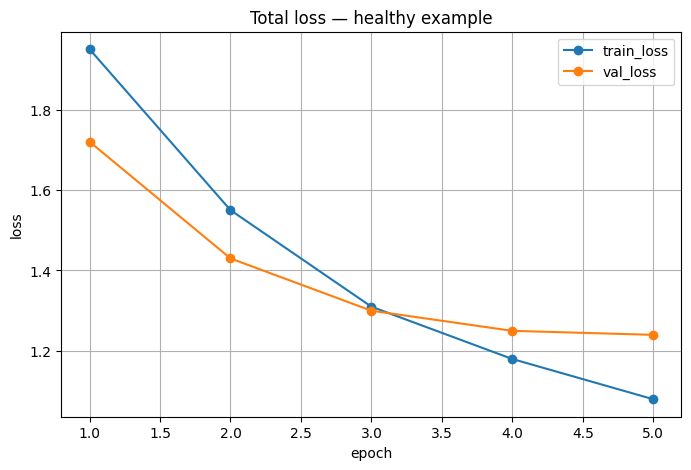

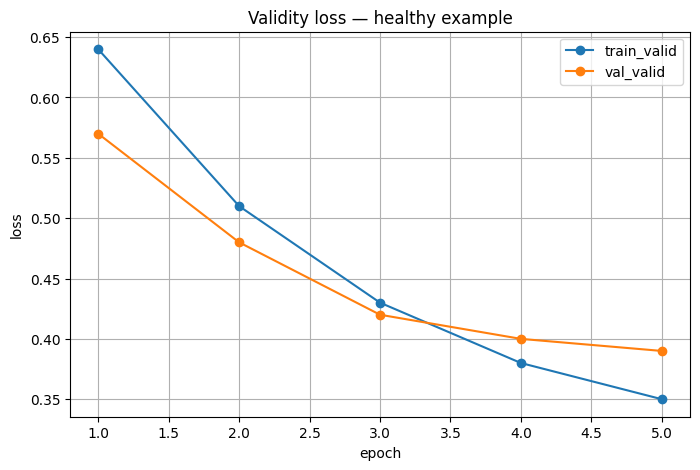

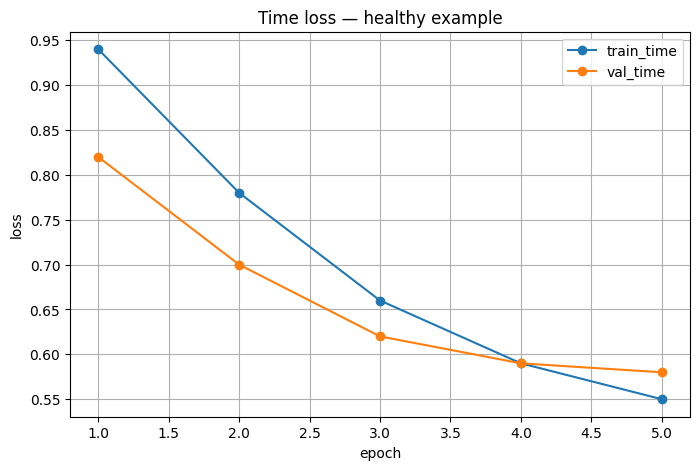

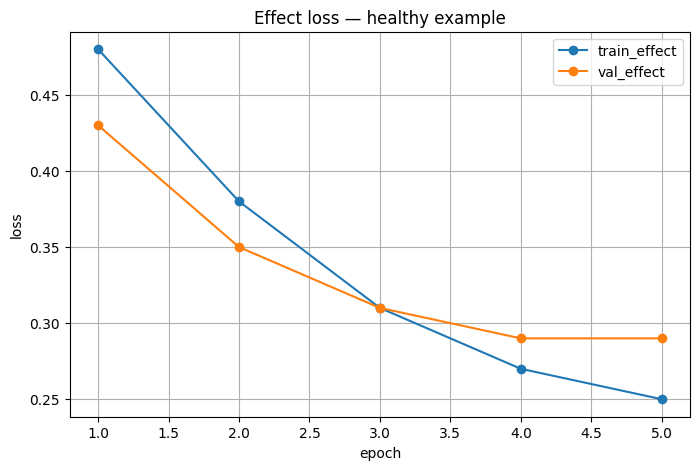

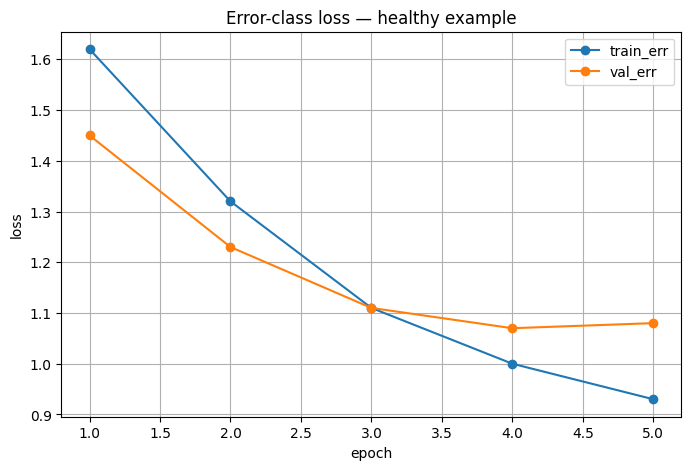

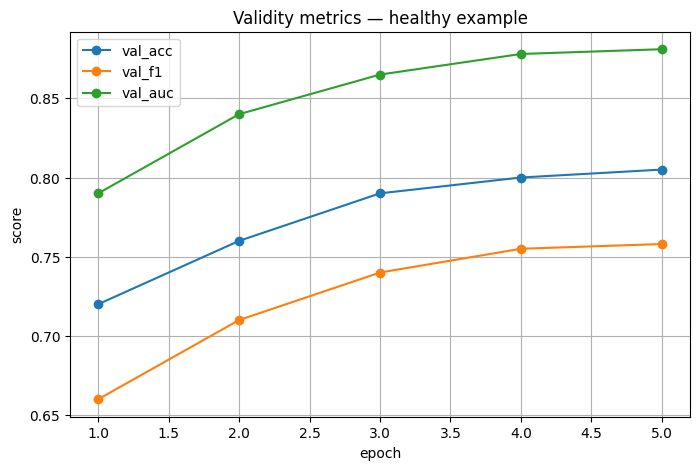

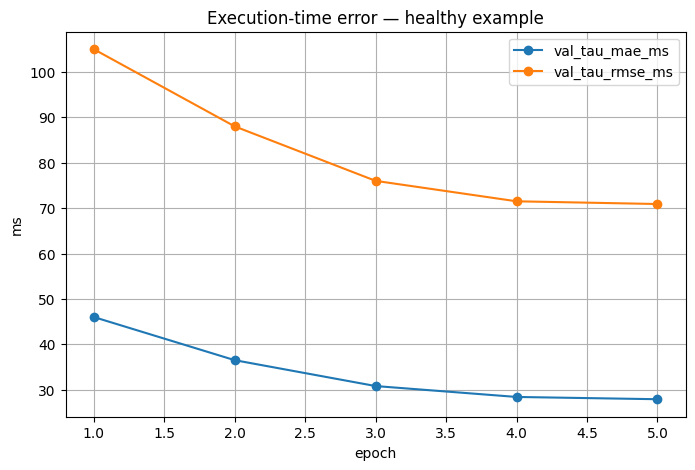

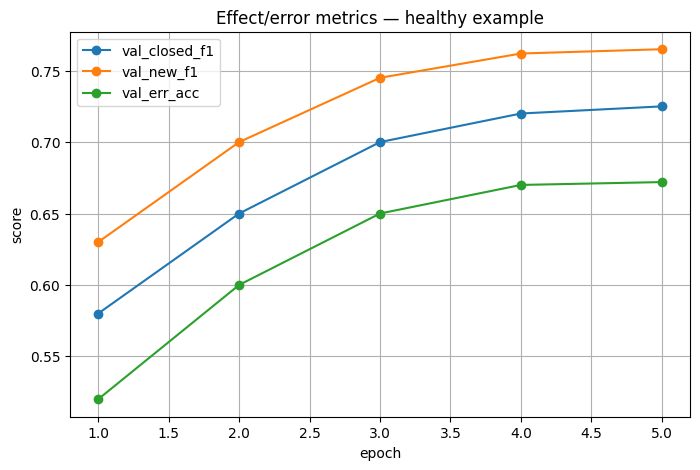

In [44]:
def plot_metric(cols, title, ylabel):
    plt.figure(figsize=(8,5))
    for c in cols:
        if c in hist.columns:
            plt.plot(hist["epoch"], hist[c], marker="o", label=c)
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_metric(["train_loss", "val_loss"], "Total loss", "loss")
plot_metric(["train_valid", "val_valid"], "Validity loss", "loss")
plot_metric(["train_time", "val_time"], "Time loss", "loss")
plot_metric(["train_effect", "val_effect"], "Effect loss", "loss")
plot_metric(["train_err", "val_err"], "Error-class loss", "loss")
plot_metric(["val_acc", "val_f1", "val_auc"], "Validity metrics", "score")
plot_metric(["val_tau_mae_ms", "val_tau_rmse_ms"], "Execution-time error", "ms")
plot_metric(["val_closed_f1", "val_new_f1", "val_err_acc"], "Effect/error metrics", "score")

In [ ]:
# Confusion matrix for success/failure
cm = confusion_matrix(val_cache["ys"], val_cache["yhat"])
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Validity confusion matrix")
plt.xlabel("pred")
plt.ylabel("true")
plt.xticks([0,1], ["fail","success"])
plt.yticks([0,1], ["fail","success"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.colorbar()
plt.show()

In [ ]:
#Predicted vs true execution time

x = val_cache["tau_true_ms"]
y = val_cache["tau_pred_ms"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=8, alpha=0.3)
lim = np.percentile(np.concatenate([x, y]), 99)
plt.plot([0, lim], [0, lim])
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.title("Predicted vs true tactic execution time")
plt.xlabel("true tau_ms")
plt.ylabel("pred tau_ms")
plt.grid(True)
plt.show()

In [ ]:
# Calibration-ish plot for valid probability

cal = pd.DataFrame({"y": val_cache["ys"], "p": val_cache["yp"]})
cal["bin"] = pd.cut(cal["p"], bins=np.linspace(0,1,11), include_lowest=True)
cal_g = cal.groupby("bin").agg(mean_p=("p","mean"), empirical_success=("y","mean"), n=("y","size")).reset_index()

plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1], "--")
plt.scatter(cal_g["mean_p"], cal_g["empirical_success"], s=np.maximum(cal_g["n"],1))
plt.title("Validity probability calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("empirical success rate")
plt.grid(True)
plt.show()

cal_g